In [60]:
import numpy as np
import matplotlib.pyplot as plt

"""
Self-contained module: all auxiliary functions (wavelengths r and b),
the v2-isolated splits, and the contraction maps H_1, H_2, H_3.

Only dependency: numpy. No local module imports -- everything is in this file,
using the same function bodies translated previously.

Input convention (same as before):
    array = [t, u, v]
    t   = array[0]          (scalar)
    u_1 = array[1][0]
    u_2 = array[1][1]
    v_1 = array[2][0]
    v_2 = array[2][1]

Vector-valued maps return numpy arrays of shape (2,).
The H maps take two such arrays: I_r = [t_r, u_r, v_r], I_b = [t_b, u_b, v_b].
"""
# ---------------------------------------------------------------------------
# Parameters -- set these to your problem's values
# ---------------------------------------------------------------------------
# n_r = 1.5143      # refractive index for wavelength r, must satisfy n_r > 1
# n_b = 1.5224      # refractive index for wavelength b, must satisfy n_b > 1
# rho_0 = 1    # rho_0 > 0
# d_0 = 2*10**(5)      # d_0 > 0
# k_0 = rho_0 / d_0
# w = np.array([0.0, 1.0])   # fixed vector w = (0, 1)

n_r = 1.1400     # refractive index for wavelength r, must satisfy n_r > 1
n_b = 1.8660      # refractive index for wavelength b, must satisfy n_b > 1
rho_0 = 2    # rho_0 > 0
d_0 = 4    # d_0 > 0
k_0 = rho_0 / d_0
w = np.array([0.0, 1.0])   # fixed vector w = (0, 1)

def _unpack(array):
    """Split the input array into t, u_1, u_2, v_1, v_2."""
    t = array[0]
    u_1 = array[1][0]
    u_2 = array[1][1]
    v_1 = array[2][0]
    v_2 = array[2][1]
    return t, u_1, u_2, v_1, v_2


# ===========================================================================
# ===========================================================================
#                       WAVELENGTH r FUNCTIONS
# ===========================================================================
# ===========================================================================

def alpha(array):
    """alpha(u) = (u_1 - sqrt((u_1^2+u_2^2)(n_r^2-1) + u_1^2)) / (u_1^2+u_2^2)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    norm_sq = u_1**2 + u_2**2
    root = np.sqrt(norm_sq * (n_r**2 - 1) + u_1**2)
    return (u_1 - root) / norm_sq


def M_r(array):
    """
    M_r(t,u) = (1/n_r) [ (sin t, cos t)
                         - alpha(u) (u_1 sin t - u_2 cos t,
                                     u_1 cos t + u_2 sin t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    vec1 = np.array([np.sin(t), np.cos(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_1 * np.cos(t) + u_2 * np.sin(t)])
    return (vec1 - a * vec2) / n_r


def D_r(array):
    """D_r(t,u) = ((n_r-1) d_0 - u_1 (1 - cos t)) / (n_r - w . M_r(t,u))."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    Mr = M_r(array)
    numerator = (n_r - 1) * d_0 - u_1 * (1 - np.cos(t))
    denominator = n_r - np.dot(w, Mr)
    return numerator / denominator


def F_r(array):
    """F_r(t,u) = u_1 (sin t, cos t) + D_r(t,u) M_r(t,u)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    return u_1 * np.array([np.sin(t), np.cos(t)]) + D_r(array) * M_r(array)


def Lambda_2r(array):
    """Lambda_{2,r}(t,u) = sqrt(1 + 1/n_r^2 - (2/n_r) w . M_r(t,u))."""
    Mr = M_r(array)
    return np.sqrt(1.0 + 1.0 / n_r**2 - (2.0 / n_r) * np.dot(w, Mr))


def alpha_tilde(array):
    """
    alpha_tilde(u,v) = (n_r^2-1) *
        ( v_1 + ((u_1 v_1 + u_2 v_2)(n_r^2-1) + u_1 v_1) / R ) * (1/(u_1 + R))^2,
    with R = sqrt((u_1^2+u_2^2)(n_r^2-1) + u_1^2).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    root = np.sqrt((u_1**2 + u_2**2) * (n_r**2 - 1) + u_1**2)
    middle = v_1 + ((u_1 * v_1 + u_2 * v_2) * (n_r**2 - 1) + u_1 * v_1) / root
    return (n_r**2 - 1) * middle * (1.0 / (u_1 + root))**2


def M_r_tilde(array):
    """
    M_r_tilde(t,u,v) = (1/n_r) [ (cos t, -sin t)
        - alpha_tilde(u,v) (u_1 sin t - u_2 cos t,  u_2 sin t + u_1 cos t)
        - alpha(u) ((u_1 - v_2) cos t + (u_2 + v_1) sin t,
                    (v_2 - u_1) sin t + (v_1 + u_2) cos t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    a_t = alpha_tilde(array)
    vec1 = np.array([np.cos(t), -np.sin(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3 = np.array([(u_1 - v_2) * np.cos(t) + (u_2 + v_1) * np.sin(t),
                     (v_2 - u_1) * np.sin(t) + (v_1 + u_2) * np.cos(t)])
    return (vec1 - a_t * vec2 - a * vec3) / n_r


def D_r_tilde(array):
    """
    D_r_tilde(t,u,v) =
        [ (v_1 (cos t - 1) - u_1 sin t)(n_r - w . M_r)
          + ((n_r-1) d_0 - u_1 (1 - cos t)) (w . M_r_tilde) ]
        / (n_r - w . M_r)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mr = np.dot(w, M_r(array))
    w_dot_Mr_t = np.dot(w, M_r_tilde(array))
    numerator = ((v_1 * (np.cos(t) - 1) - u_1 * np.sin(t)) * (n_r - w_dot_Mr)
                 + ((n_r - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Mr_t)
    return numerator / (n_r - w_dot_Mr)**2


def F_r_tilde(array):
    """
    F_r_tilde(t,u,v) = u_1 (cos t, -sin t) + v_1 (sin t, cos t)
                       + M_r_tilde(t,u,v) D_r(t,u) + M_r(t,u) D_r_tilde(t,u,v).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    term1 = u_1 * np.array([np.cos(t), -np.sin(t)])
    term2 = v_1 * np.array([np.sin(t), np.cos(t)])
    return term1 + term2 + M_r_tilde(array) * D_r(array) + M_r(array) * D_r_tilde(array)


def Lambda_2r_tilde(array):
    """Lambda_2r_tilde(t,u,v) = -(1/n_r) (w . M_r_tilde) / Lambda_2r(t,u)."""
    return -(1.0 / n_r) * np.dot(w, M_r_tilde(array)) / Lambda_2r(array)


# ===========================================================================
# ===========================================================================
#                       WAVELENGTH b FUNCTIONS
# ===========================================================================
# ===========================================================================

def alpha_b(array):
    """alpha_b(u) = (u_1 - sqrt((u_1^2+u_2^2)(n_b^2-1) + u_1^2)) / (u_1^2+u_2^2)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    norm_sq = u_1**2 + u_2**2
    root = np.sqrt(norm_sq * (n_b**2 - 1) + u_1**2)
    return (u_1 - root) / norm_sq


def M_b(array):
    """
    M_b(t,u) = (1/n_b) [ (sin t, cos t)
                         - alpha_b(u) (u_1 sin t - u_2 cos t,
                                       u_1 cos t + u_2 sin t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha_b(array)
    vec1 = np.array([np.sin(t), np.cos(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_1 * np.cos(t) + u_2 * np.sin(t)])
    return (vec1 - a * vec2) / n_b


def D_b(array):
    """D_b(t,u) = ((n_b-1) d_0 - u_1 (1 - cos t)) / (n_b - w . M_b(t,u))."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    Mb = M_b(array)
    numerator = (n_b - 1) * d_0 - u_1 * (1 - np.cos(t))
    denominator = n_b - np.dot(w, Mb)
    return numerator / denominator


def F_b(array):
    """F_b(t,u) = u_1 (sin t, cos t) + D_b(t,u) M_b(t,u)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    return u_1 * np.array([np.sin(t), np.cos(t)]) + D_b(array) * M_b(array)


def Lambda_2b(array):
    """Lambda_{2,b}(t,u) = sqrt(1 + 1/n_b^2 - (2/n_b) w . M_b(t,u))."""
    Mb = M_b(array)
    return np.sqrt(1.0 + 1.0 / n_b**2 - (2.0 / n_b) * np.dot(w, Mb))


def alpha_tilde_b(array):
    """
    alpha_tilde_b(u,v) = (n_b^2-1) *
        ( v_1 + ((u_1 v_1 + u_2 v_2)(n_b^2-1) + u_1 v_1) / R ) * (1/(u_1 + R))^2,
    with R = sqrt((u_1^2+u_2^2)(n_b^2-1) + u_1^2).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    root = np.sqrt((u_1**2 + u_2**2) * (n_b**2 - 1) + u_1**2)
    middle = v_1 + ((u_1 * v_1 + u_2 * v_2) * (n_b**2 - 1) + u_1 * v_1) / root
    return (n_b**2 - 1) * middle * (1.0 / (u_1 + root))**2


def M_b_tilde(array):
    """
    M_b_tilde(t,u,v) = (1/n_b) [ (cos t, -sin t)
        - alpha_tilde_b(u,v) (u_1 sin t - u_2 cos t,  u_2 sin t + u_1 cos t)
        - alpha_b(u) ((u_1 - v_2) cos t + (u_2 + v_1) sin t,
                      (v_2 - u_1) sin t + (v_1 + u_2) cos t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha_b(array)
    a_t = alpha_tilde_b(array)
    vec1 = np.array([np.cos(t), -np.sin(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3 = np.array([(u_1 - v_2) * np.cos(t) + (u_2 + v_1) * np.sin(t),
                     (v_2 - u_1) * np.sin(t) + (v_1 + u_2) * np.cos(t)])
    return (vec1 - a_t * vec2 - a * vec3) / n_b


def D_b_tilde(array):
    """
    D_b_tilde(t,u,v) =
        [ (v_1 (cos t - 1) - u_1 sin t)(n_b - w . M_b)
          + ((n_b-1) d_0 - u_1 (1 - cos t)) (w . M_b_tilde) ]
        / (n_b - w . M_b)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mb = np.dot(w, M_b(array))
    w_dot_Mb_t = np.dot(w, M_b_tilde(array))
    numerator = ((v_1 * (np.cos(t) - 1) - u_1 * np.sin(t)) * (n_b - w_dot_Mb)
                 + ((n_b - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Mb_t)
    return numerator / (n_b - w_dot_Mb)**2


def F_b_tilde(array):
    """
    F_b_tilde(t,u,v) = u_1 (cos t, -sin t) + v_1 (sin t, cos t)
                       + M_b_tilde(t,u,v) D_b(t,u) + M_b(t,u) D_b_tilde(t,u,v).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    term1 = u_1 * np.array([np.cos(t), -np.sin(t)])
    term2 = v_1 * np.array([np.sin(t), np.cos(t)])
    return term1 + term2 + M_b_tilde(array) * D_b(array) + M_b(array) * D_b_tilde(array)


def Lambda_2b_tilde(array):
    """Lambda_2b_tilde(t,u,v) = -(1/n_b) (w . M_b_tilde) / Lambda_2b(t,u)."""
    return -(1.0 / n_b) * np.dot(w, M_b_tilde(array)) / Lambda_2b(array)


# ===========================================================================
# ===========================================================================
#         v2-ISOLATED SPLITS (wavelength r):
#         f_tilde(t,u,v) = v_2 * f_tilde_v2 + f_tilde_others
# ===========================================================================
# ===========================================================================

def alpha_tilde_v2(array):
    """
    Coefficient of v_2 in alpha_tilde:
    alpha_tilde_v2(u) = (n_r^2-1) * (u_2 (n_r^2-1) / R) * (1/(u_1+R))^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    R = np.sqrt((u_1**2 + u_2**2) * (n_r**2 - 1) + u_1**2)
    return (n_r**2 - 1) * (u_2 * (n_r**2 - 1) / R) * (1.0 / (u_1 + R))**2


def alpha_tilde_others(array):
    """
    v_2-free part of alpha_tilde (= alpha_tilde with v_2 set to 0):
    (n_r^2-1) * ( v_1 + (u_1 v_1 (n_r^2-1) + u_1 v_1)/R ) * (1/(u_1+R))^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    R = np.sqrt((u_1**2 + u_2**2) * (n_r**2 - 1) + u_1**2)
    middle = v_1 + (u_1 * v_1 * (n_r**2 - 1) + u_1 * v_1) / R
    return (n_r**2 - 1) * middle * (1.0 / (u_1 + R))**2


def M_r_tilde_v2(array):
    """
    M_r_tilde_v2(t,u,v) = (1/n_r) [ - alpha_tilde_v2(u) (u_1 sin t - u_2 cos t,
                                                         u_2 sin t + u_1 cos t)
                                    - alpha(u) (-cos t, sin t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    a_v2 = alpha_tilde_v2(array)
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3_v2 = np.array([-np.cos(t), np.sin(t)])
    return (-a_v2 * vec2 - a * vec3_v2) / n_r


def M_r_tilde_others(array):
    """
    M_r_tilde_others(t,u,v) = (1/n_r) [ (cos t, -sin t)
        - alpha_tilde_others(u,v) (u_1 sin t - u_2 cos t,  u_2 sin t + u_1 cos t)
        - alpha(u) (u_1 cos t + (u_2+v_1) sin t,  -u_1 sin t + (v_1+u_2) cos t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    a_oth = alpha_tilde_others(array)
    vec1 = np.array([np.cos(t), -np.sin(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3_oth = np.array([u_1 * np.cos(t) + (u_2 + v_1) * np.sin(t),
                         -u_1 * np.sin(t) + (v_1 + u_2) * np.cos(t)])
    return (vec1 - a_oth * vec2 - a * vec3_oth) / n_r


def D_r_tilde_v2(array):
    """
    D_r_tilde_v2 = ((n_r-1) d_0 - u_1 (1 - cos t)) (w . M_r_tilde_v2)
                   / (n_r - w . M_r)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mr = np.dot(w, M_r(array))
    w_dot_Mv2 = np.dot(w, M_r_tilde_v2(array))
    return ((n_r - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Mv2 / (n_r - w_dot_Mr)**2


def D_r_tilde_others(array):
    """
    D_r_tilde_others = [ (v_1 (cos t - 1) - u_1 sin t)(n_r - w . M_r)
                         + ((n_r-1) d_0 - u_1 (1 - cos t)) (w . M_r_tilde_others) ]
                       / (n_r - w . M_r)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mr = np.dot(w, M_r(array))
    w_dot_Moth = np.dot(w, M_r_tilde_others(array))
    numerator = ((v_1 * (np.cos(t) - 1) - u_1 * np.sin(t)) * (n_r - w_dot_Mr)
                 + ((n_r - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Moth)
    return numerator / (n_r - w_dot_Mr)**2


def F_r_tilde_v2(array):
    """F_r_tilde_v2 = M_r_tilde_v2 * D_r + M_r * D_r_tilde_v2."""
    return M_r_tilde_v2(array) * D_r(array) + M_r(array) * D_r_tilde_v2(array)


def F_r_tilde_others(array):
    """
    F_r_tilde_others = u_1 (cos t, -sin t) + v_1 (sin t, cos t)
                       + M_r_tilde_others * D_r + M_r * D_r_tilde_others.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    term1 = u_1 * np.array([np.cos(t), -np.sin(t)])
    term2 = v_1 * np.array([np.sin(t), np.cos(t)])
    return (term1 + term2
            + M_r_tilde_others(array) * D_r(array)
            + M_r(array) * D_r_tilde_others(array))


def Lambda_2r_tilde_v2(array):
    """Lambda_2r_tilde_v2 = -(1/n_r) (w . M_r_tilde_v2) / Lambda_2r."""
    return -(1.0 / n_r) * np.dot(w, M_r_tilde_v2(array)) / Lambda_2r(array)


def Lambda_2r_tilde_others(array):
    """Lambda_2r_tilde_others = -(1/n_r) (w . M_r_tilde_others) / Lambda_2r."""
    return -(1.0 / n_r) * np.dot(w, M_r_tilde_others(array)) / Lambda_2r(array)


# ===========================================================================
# ===========================================================================
#               CONTRACTION MAPS H_1, H_2, H_3
#               I_r = [t_r, u_r, v_r],  I_b = [t_b, u_b, v_b]
# ===========================================================================
# ===========================================================================

def H_1(I_r, I_b):
    """H_1(I_r, I_b) = F_r_tilde_1(I_r) / F_b_tilde_1(I_b)."""
    return F_r_tilde(I_r)[0] / F_b_tilde(I_b)[0]


def H_2(I_r, I_b):
    """H_2(I_r, I_b) = u_{r2}  (second component of u_r)."""
    return I_r[1][1]


def H_3(I_r, I_b):
    """
    H_3(I_r, I_b) = the value of v_2 (= z_3'(t)) isolated from

        F_r_tilde_1(I_r) (M_r1(I_r) Lambda_2b_tilde(I_b) - M_b1_tilde(I_b) Lambda_2r(I_r))
      = F_b_tilde_1(I_b) (M_r1_tilde(I_r) Lambda_2b(I_b) - M_b1(I_b) Lambda_2r_tilde(I_r)),

    namely

        [ F_b_tilde_1(I_b) (M_r1_tilde_others(I_r) Lambda_2b(I_b)
                            - M_b1(I_b) Lambda_2r_tilde_others(I_r))
          - F_r_tilde_1_others(I_r) (M_r1(I_r) Lambda_2b_tilde(I_b)
                                     - M_b1_tilde(I_b) Lambda_2r(I_r)) ]
        /
        [ F_r_tilde_1_v2(I_r) (M_r1(I_r) Lambda_2b_tilde(I_b)
                               - M_b1_tilde(I_b) Lambda_2r(I_r))
          - F_b_tilde_1(I_b) (M_r1_tilde_v2(I_r) Lambda_2b(I_b)
                              - M_b1(I_b) Lambda_2r_tilde_v2(I_r)) ].
    """
    # --- pieces evaluated at I_r (wavelength r) ---
    Mr1 = M_r(I_r)[0]                          # M_r1(I_r)
    Lam_r = Lambda_2r(I_r)                     # Lambda_2r(I_r)
    Mr1_oth = M_r_tilde_others(I_r)[0]         # M_r1_tilde_others(I_r)
    Mr1_v2 = M_r_tilde_v2(I_r)[0]              # M_r1_tilde_v2(I_r)
    LamT_r_oth = Lambda_2r_tilde_others(I_r)   # Lambda_2r_tilde_others(I_r)
    LamT_r_v2 = Lambda_2r_tilde_v2(I_r)        # Lambda_2r_tilde_v2(I_r)
    Fr1_oth = F_r_tilde_others(I_r)[0]         # F_r1_tilde_others(I_r)
    Fr1_v2 = F_r_tilde_v2(I_r)[0]              # F_r1_tilde_v2(I_r)

    # --- pieces evaluated at I_b (wavelength b, full functions) ---
    Fb1_t = F_b_tilde(I_b)[0]                  # F_b1_tilde(I_b)
    Mb1 = M_b(I_b)[0]                          # M_b1(I_b)
    Mb1_t = M_b_tilde(I_b)[0]                  # M_b1_tilde(I_b)
    Lam_b = Lambda_2b(I_b)                     # Lambda_2b(I_b)
    LamT_b = Lambda_2b_tilde(I_b)              # Lambda_2b_tilde(I_b)

    # common bracket appearing in numerator and denominator
    bracket = Mr1 * LamT_b - Mb1_t * Lam_r     # M_r1 Lambda_2b_tilde - M_b1_tilde Lambda_2r

    numerator = (Fb1_t * (Mr1_oth * Lam_b - Mb1 * LamT_r_oth)
                 - Fr1_oth * bracket)
    denominator = (Fr1_v2 * bracket
                   - Fb1_t * (Mr1_v2 * Lam_b - Mb1 * LamT_r_v2))
    return numerator / denominator


# ===========================================================================
# Admissible point P  (eq:admissible P)
# ===========================================================================

def Delta_r():
    """Delta_r = n_r / (n_r - 1)."""
    return n_r / (n_r - 1)


def Delta_b():
    """Delta_b = n_b / (n_b - 1)."""
    return n_b / (n_b - 1)


def P(k_0):
    """
    P = ( (Db - Dr + S) / (Dr - Db + S),
          0,
          ((Db + Dr + S) / 2) * rho_0 ),
    where Dr = Delta_r, Db = Delta_b, k_0 = rho_0 / d_0,
    and S = sqrt((Db - Dr)^2 - 4 k_0 Db Dr).
    Returns np.array([P_1, P_2, P_3]).
    """
    Dr = Delta_r()
    Db = Delta_b()
    # k_0 = rho_0 / d_0

    discriminant = (Db - Dr)**2 - 4.0 * k_0 * Db * Dr
    if discriminant < 0:
        raise ValueError(
            f"Negative discriminant ({discriminant:.6e}): "
            "(Delta_b - Delta_r)^2 - 4 k_0 Delta_b Delta_r < 0 for the "
            "current n_r, n_b, rho_0, d_0 -- P is not real."
        )
    S = np.sqrt(discriminant)

    P_1 = (Db - Dr + S) / (Dr - Db + S)
    P_2 = 0.0
    P_3 = ((Db + Dr + S) / 2.0) * rho_0

    return np.array([P_1, P_2, P_3])

In [126]:
from scipy.integrate import quad
from scipy.integrate import quad_vec
from scipy.interpolate import CubicSpline

delta = 0.95/4
k = 300
dinterval = np.linspace(-delta, delta, k)
def findingsolution(k_0, n , tol):
    def g(t):
        return t*P(k_0)
    def dg(t):
        return P(k_0)

    def h_t(t, g, dg):
        f = g(t) 
        df = dg(t)
        h_2 = f[2] #z_2'(t)=z_3(t)

        I_r = [t, [f[1]+rho_0, f[2]], [h_2, 0]]
        I_b = [f[0], [g(f[0])[1]+rho_0, g(f[0])[2]], dg(f[0])[1:]] 
        
        h_3 = H_3(I_r, I_b)

        I_r[2][1] = h_3 # z_3'(t)=H_3(t)

        h_1 = H_1(I_r, I_b)
        return np.array([h_1, h_2, h_3])
    
    def H_t(t):
        return h_t(t, g, dg)

    k = dinterval.size
    Z_array = np.zeros((n, k , 3))
    
    for i in np.arange( n):
        print(f"i={i}")
        if i == 0:
            for j in np.arange(k):
                Z_array[i][j] = g(dinterval[j])
            continue   

        for j in np.arange(k):
            print(f"j={j}")
            Z_array[i][j], err, info = quad_vec(H_t, 0, dinterval[j], full_output= True, limit=n, epsabs = tol, epsrel = tol )
            print("Integral done")
            print(f"Final error reached: {err}")
             
            if not info.success:
                print(f"Convergence failed! Message: {info.message}")
                
                break
            
        if not info.success:
            break
        
        diff = Z_array[i] - Z_array[i-1]

        # Euclidean norm at each time point, shape (N,)
        norms = np.linalg.norm(diff, axis=1)

        # Worst case over the interval
        max_norm = np.max(norms)      
        if max_norm < tol:
            break
        else:
            print(f'norms:{norms}')
            print(f"max_norm = {max_norm}")

        g = CubicSpline(dinterval, Z_array[i])
        dg = g.derivative()
        print("interpolation done")
        def H_t(t):
                return h_t(t, g, dg)  
                      
    return Z_array, i

arr2, index = findingsolution(k_0=k_0,n = 1000, tol = 1e-12)
 

i=0
i=1
j=0
Integral done
Final error reached: 2.1673631593100774e-13
j=1
Integral done
Final error reached: 2.1447816368994037e-13
j=2
Integral done
Final error reached: 6.369053125196232e-13
j=3
Integral done
Final error reached: 3.994120039571743e-13
j=4
Integral done
Final error reached: 2.760637263881141e-13
j=5
Integral done
Final error reached: 2.11199274934993e-13
j=6
Integral done
Final error reached: 1.7654348661513928e-13
j=7
Integral done
Final error reached: 1.6943402357395054e-13
j=8
Integral done
Final error reached: 1.6773529842633424e-13
j=9
Integral done
Final error reached: 1.6605308555796824e-13
j=10
Integral done
Final error reached: 1.643867951194975e-13
j=11
Integral done
Final error reached: 1.627358788789696e-13
j=12
Integral done
Final error reached: 1.610998260806385e-13
j=13
Integral done
Final error reached: 1.5947815980693372e-13
j=14
Integral done
Final error reached: 1.578704337714953e-13
j=15
Integral done
Final error reached: 1.562762294836313e-13
j=16

In [ ]:
rho_array = arr2[index,:,1] + rho_0
rho_array 

rho =  CubicSpline(dinterval, rho_array)
drho = rho.derivative()

xrho = np.zeros((dinterval.size, 2))
for i in np.arange(dinterval.size):
    xrho[i] =rho_array[i]*np.array([np.sin(dinterval[i]), np.cos(dinterval[i])])

dr_array = np.zeros((rho_array.size))
for i in np.arange(rho_array.size):
    dr_array[i] = D_r([dinterval[i],[rho_array[i], arr2[index,i,2]],[0,0]])

Mr_array = np.zeros((rho_array.size,2))
for i in np.arange(rho_array.size):
    Mr_array[i] = M_r([dinterval[i],[rho_array[i], arr2[index,i,2]],[0,0]])

Fr_array = np.zeros((rho_array.size,2))
for i in np.arange(rho_array.size):
    Fr_array[i] = F_r([dinterval[i],[rho_array[i], arr2[index,i,2]],[0,0]])

def refract(x, nu, n1, n2):
    """
    Formula
    -------
    mu = x.nu - sqrt((n2/n1)^2 - 1 + (x.nu)^2)
    m  = (n1/n2) * (x - mu * nu)
    """
    x  = np.asarray(x,  dtype=float)
    nu = np.asarray(nu, dtype=float)

    x_dot_nu = np.dot(x, nu)

    discriminant = (n2/n1)**2 - 1.0 + x_dot_nu**2

    if discriminant < 0:
        return None                     # total internal reflection

    mu = x_dot_nu - np.sqrt(discriminant)
    m  = (n1/n2) * (x - mu * nu)

    return m / np.linalg.norm(m)       # normalise for safety

wr_array = np.zeros((dinterval.size,2))
for i in np.arange(dinterval.size-1):
    tangent = (Fr_array[i+1] - Fr_array[i])
    normal  = np.array([-tangent[1], tangent[0]])   # rotate 90°
    normal  = normal / np.linalg.norm(normal)
    wr_array[i] =refract(Mr_array[i], normal ,n_r,1 )


In [128]:
Fr_array

array([[-5.03703108e-01,  6.08192083e+00],
       [-4.97575592e-01,  6.07991255e+00],
       [-4.91539344e-01,  6.07795963e+00],
       [-4.85591760e-01,  6.07606002e+00],
       [-4.79730340e-01,  6.07421181e+00],
       [-4.73952680e-01,  6.07241315e+00],
       [-4.68256470e-01,  6.07066229e+00],
       [-4.62639485e-01,  6.06895755e+00],
       [-4.57099585e-01,  6.06729735e+00],
       [-4.51634708e-01,  6.06568017e+00],
       [-4.46242867e-01,  6.06410454e+00],
       [-4.40922146e-01,  6.06256907e+00],
       [-4.35670699e-01,  6.06107245e+00],
       [-4.30486742e-01,  6.05961340e+00],
       [-4.25368553e-01,  6.05819070e+00],
       [-4.20314470e-01,  6.05680320e+00],
       [-4.15322887e-01,  6.05544976e+00],
       [-4.10392251e-01,  6.05412933e+00],
       [-4.05521060e-01,  6.05284088e+00],
       [-4.00707860e-01,  6.05158342e+00],
       [-3.95951247e-01,  6.05035601e+00],
       [-3.91249858e-01,  6.04915775e+00],
       [-3.86602376e-01,  6.04798776e+00],
       [-3.

In [140]:

rhob_array = rho(arr2[index,:,0])
drhob_array = drho(arr2[index,:,0])

db_array = np.zeros((rho_array.size))

brho = np.zeros((dinterval.size, 2))
for i in np.arange(dinterval.size):
    brho[i] =rhob_array[i]*np.array([np.sin(arr2[index,i,0]), np.cos(arr2[index,i,0])])

for i in np.arange(rho_array.size):
    db_array[i] = D_b([arr2[index,i,0],[rhob_array[i], drhob_array[i]],[0,0]])

Mb_array = np.zeros((rho_array.size,2))
for i in np.arange(rho_array.size):
    Mb_array[i] = M_b([arr2[index,i,0],[rhob_array[i], drhob_array[i]],[0,0]])

Fb_array = np.zeros((rho_array.size,2))
for i in np.arange(rho_array.size):
    Fb_array[i] = F_b([arr2[index,i,0],[rhob_array[i], drhob_array[i]],[0,0]])

wb_array = np.zeros((dinterval.size,2))
for i in np.arange(dinterval.size-1):
    tangent = (Fb_array[i+1] - Fb_array[i])
    normal  = np.array([tangent[1],- tangent[0]])   # rotate 90°
    normal  = normal / np.linalg.norm(normal)
    wb_array[i] =refract(Mb_array[i], normal ,n_b,1 )


In [141]:
Fb_array

array([[-5.03703094e-01,  5.91708051e+00],
       [-4.97575593e-01,  5.91913783e+00],
       [-4.91539357e-01,  5.92113722e+00],
       [-4.85591728e-01,  5.92308089e+00],
       [-4.79730372e-01,  5.92497086e+00],
       [-4.73952659e-01,  5.92680916e+00],
       [-4.68256475e-01,  5.92859762e+00],
       [-4.62639501e-01,  5.93033804e+00],
       [-4.57099552e-01,  5.93203215e+00],
       [-4.51634737e-01,  5.93368151e+00],
       [-4.46242867e-01,  5.93528773e+00],
       [-4.40922116e-01,  5.93685227e+00],
       [-4.35670732e-01,  5.93837650e+00],
       [-4.30486734e-01,  5.93986184e+00],
       [-4.25368525e-01,  5.94130952e+00],
       [-4.20314503e-01,  5.94272079e+00],
       [-4.15322880e-01,  5.94409685e+00],
       [-4.10392221e-01,  5.94543881e+00],
       [-4.05521091e-01,  5.94674774e+00],
       [-4.00707862e-01,  5.94802471e+00],
       [-3.95951214e-01,  5.94927070e+00],
       [-3.91249883e-01,  5.95048664e+00],
       [-3.86602392e-01,  5.95167349e+00],
       [-3.

In [142]:
wb_array

array([[ 6.01936625e-01, -7.98543862e-01],
       [ 5.95449743e-01, -8.03392559e-01],
       [ 5.89029103e-01, -8.08111821e-01],
       [ 5.82673694e-01, -8.12706200e-01],
       [ 5.76382354e-01, -8.17180140e-01],
       [ 5.70154103e-01, -8.21537765e-01],
       [ 5.63987857e-01, -8.25783081e-01],
       [ 5.57882559e-01, -8.29919906e-01],
       [ 5.51837268e-01, -8.33951815e-01],
       [ 5.45850882e-01, -8.37882339e-01],
       [ 5.39922428e-01, -8.41714780e-01],
       [ 5.34050992e-01, -8.45452268e-01],
       [ 5.28235507e-01, -8.49097903e-01],
       [ 5.22475052e-01, -8.52654572e-01],
       [ 5.16768746e-01, -8.56125028e-01],
       [ 5.11115568e-01, -8.59511999e-01],
       [ 5.05514637e-01, -8.62818029e-01],
       [ 4.99965121e-01, -8.66045540e-01],
       [ 4.94466043e-01, -8.69196947e-01],
       [ 4.89016548e-01, -8.72274507e-01],
       [ 4.83615865e-01, -8.75280352e-01],
       [ 4.78263066e-01, -8.78216625e-01],
       [ 4.72957314e-01, -8.81085341e-01],
       [ 4.

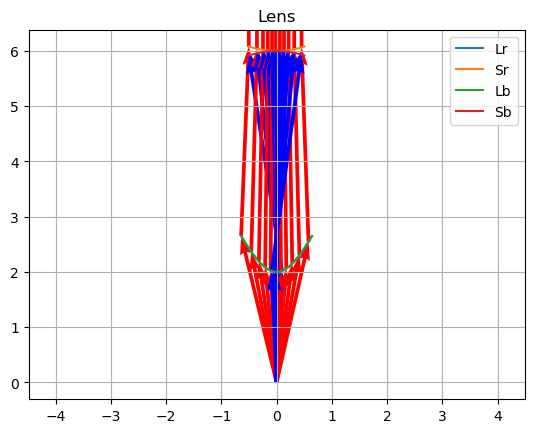

In [145]:
step = 29
up = k
low = 0
xr_vectors = xrho[low:up][::step]
xb_vectors = brho[low:up][::step]

mr_vectors  = Mr_array[low:up][::step]
dr_vectors  = dr_array[low:up][::step]
wr_vectors = wr_array[low:up][::step]
fr_vectors = Fr_array[low:up][::step]

mb_vectors  = Mb_array[low:up][::step]
db_vectors  = db_array[low:up][::step]
wb_vectors = wb_array[low:up][::step]
fb_vectors = Fb_array[low:up][::step]

plt.figure()
plt.plot((xrho[low:up])[:,0],(xrho[low:up])[:,1], label = 'Lr')
plt.plot((Fr_array[low:up])[:,0],(Fr_array[low:up])[:,1], label = 'Sr')

plt.plot((xrho[low:up])[:,0],(xrho[low:up])[:,1], label = 'Lb')
plt.plot((Fb_array[low:up])[:,0],(Fb_array[low:up])[:,1], label = 'Sb')


for i in np.arange(dinterval[low:up][::step].size):
    plt.quiver(0, 0, xr_vectors[i,0], xr_vectors[i,1], angles='xy', scale_units='xy', scale=1, color='red', lw = 1)
    plt.quiver(xr_vectors[i,0], xr_vectors[i,1], dr_vectors[i] * mr_vectors[i, 0], dr_vectors[i] * mr_vectors[i, 1], angles='xy', scale_units='xy', scale=1, color='red', lw = 1)
    plt.quiver(fr_vectors[i,0], fr_vectors[i,1], wr_vectors[i,0], wr_vectors[i,1], angles='xy', scale_units='xy', scale=1, color='red', lw = 1)

    plt.quiver(0, 0, xb_vectors[i,0], xb_vectors[i,1], angles='xy', scale_units='xy', scale=1, color='blue', lw = 1)
    plt.quiver(xb_vectors[i,0], xb_vectors[i,1], db_vectors[i] * mb_vectors[i, 0], db_vectors[i] * mb_vectors[i, 1], angles='xy', scale_units='xy', scale=1, color='blue', lw = 1)
    plt.quiver(fb_vectors[i,0], fb_vectors[i,1], wb_vectors[i,0], wb_vectors[i,1], angles='xy', scale_units='xy', scale=1, color='blue', lw = 1)


plt.legend()
plt.title("Lens")
plt.grid(True)
plt.axis('equal')
# plt.gca().set_aspect('equal', adjustable='box')
plt.show()

(-2.0, 2.0)

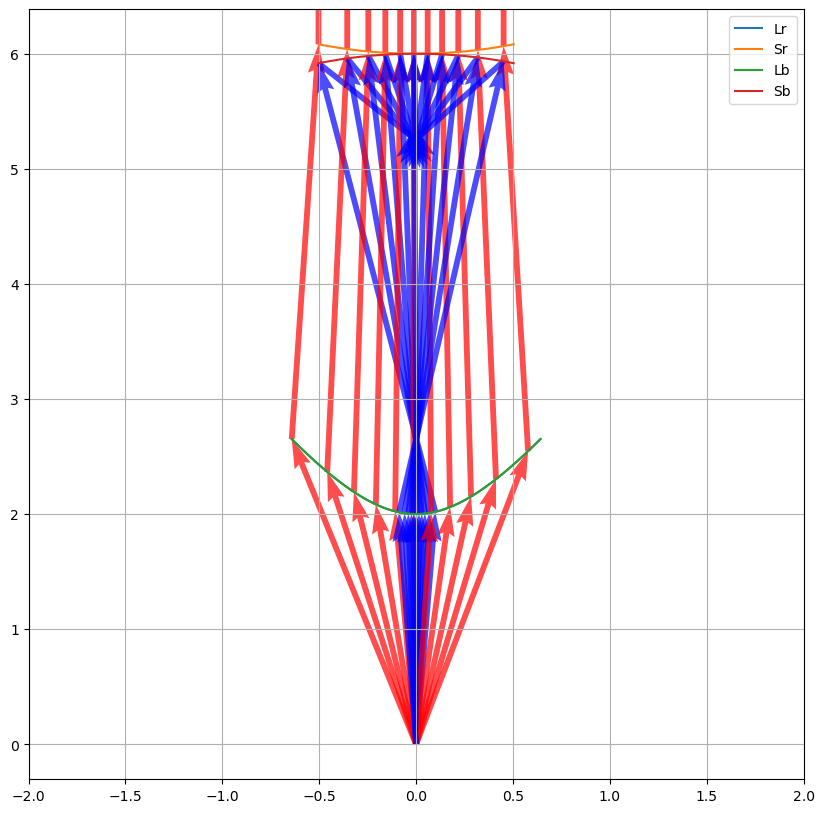

In [147]:
step = 29
up = k
low = 0
xr_vectors = xrho[low:up][::step]

mr_vectors  = Mr_array[low:up][::step]
dr_vectors  = dr_array[low:up][::step]
wr_vectors = wr_array[low:up][::step]
fr_vectors = Fr_array[low:up][::step]

mb_vectors  = Mb_array[low:up][::step]
db_vectors  = db_array[low:up][::step]
wb_vectors = wb_array[low:up][::step]
fb_vectors = Fb_array[low:up][::step]

fig, ax = plt.subplots(figsize=(10, 10), dpi=100)

ax.plot((xrho[low:up])[:,0],(xrho[low:up])[:,1], label = 'Lr')
ax.plot((Fr_array[low:up])[:,0],(Fr_array[low:up])[:,1], label = 'Sr')

ax.plot((xrho[low:up])[:,0],(xrho[low:up])[:,1], label = 'Lb')
ax.plot((Fb_array[low:up])[:,0],(Fb_array[low:up])[:,1], label = 'Sb')


for i in np.arange(dinterval[low:up][::step].size):
    ax.quiver(0, 0, xr_vectors[i,0], xr_vectors[i,1], angles='xy', scale_units='xy', scale=1, color='red', lw = 1, alpha = 0.7)
    ax.quiver(xr_vectors[i,0], xr_vectors[i,1], dr_vectors[i] * mr_vectors[i, 0], dr_vectors[i] * mr_vectors[i, 1], angles='xy', scale_units='xy', scale=1, color='red', lw = 1, alpha = 0.7)
    ax.quiver(fr_vectors[i,0], fr_vectors[i,1], wr_vectors[i,0], wr_vectors[i,1], angles='xy', scale_units='xy', scale=1, color='red', lw = 1, alpha = 0.7)

    ax.quiver(0, 0, xb_vectors[i,0], xb_vectors[i,1], angles='xy', scale_units='xy', scale=1, color='blue', lw = 1, alpha = 0.7)
    ax.quiver(xb_vectors[i,0], xb_vectors[i,1], db_vectors[i] * mb_vectors[i, 0], db_vectors[i] * mb_vectors[i, 1], angles='xy', scale_units='xy', scale=1, color='blue', lw = 1, alpha = 0.7)
    ax.quiver(fb_vectors[i,0], fb_vectors[i,1], wb_vectors[i,0], wb_vectors[i,1], angles='xy', scale_units='xy', scale=1, color='blue', lw = 1, alpha = 0.7)


ax.legend()
# ax.title("Lens")
ax.grid(True)
# ax.axis('equal')
# ax.gca().set_aspect('equal', adjustable='box')
ax.set_xlim(-2, 2)    # set your desired x range
# ax.set_ylim(5.9, 6.1)    # set your desired y range


In [134]:
g_final = CubicSpline(dinterval, arr2[index, :, :])

cond_r = np.zeros(dinterval.size)
cond_b = np.zeros(dinterval.size)
for i in range(dinterval.size):
    t   = dinterval[i]
    u_r = [arr2[index, i, 1] + rho_0, arr2[index, i, 2]]
    cond_r[i] = np.dot(w, M_r([t, u_r, [0, 0]])) - 1.0/n_r

    t_b = arr2[index, i, 0]              # z_1(t)
    Zb  = g_final(t_b)                   # Z(z_1(t))
    u_b = [Zb[1] + rho_0, Zb[2]]
    cond_b[i] = np.dot(w, M_b([t_b, u_b, [0, 0]])) - 1.0/n_b

print("min (w·M_r - 1/n_r):", cond_r.min(), " (must be >= 0)")
print("min (w·M_b - 1/n_b):", cond_b.min(), " (must be >= 0)")
print("blue violations:", np.sum(cond_b < 0), "of", dinterval.size)

min (w·M_r - 1/n_r): 0.12199691775699717  (must be >= 0)
min (w·M_b - 1/n_b): 0.45233523704230116  (must be >= 0)
blue violations: 0 of 300


AttributeError: module 'matplotlib.pyplot' has no attribute 'set_xlim'

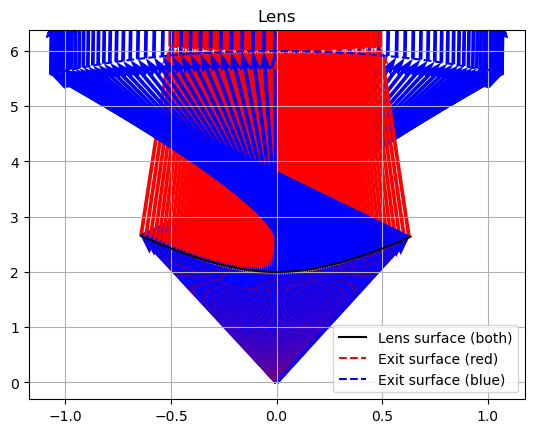

In [135]:
# ── First surface: SAME physical surface for both colors ─────────────────────
rho_array = arr2[index, :, 1] + rho_0      # u_1 = z_2(t) + rho_0

xrho = np.zeros((dinterval.size, 2))
for i in np.arange(dinterval.size):
    xrho[i] = rho_array[i] * np.array([np.sin(dinterval[i]),
                                        np.cos(dinterval[i])])

# ── Red: M_r, D_r, F_r ───────────────────────────────────────────────────────
dr_array = np.zeros(rho_array.size)
Mr_array = np.zeros((rho_array.size, 2))
Fr_array = np.zeros((rho_array.size, 2))
for i in np.arange(rho_array.size):
    state = [dinterval[i], [rho_array[i], arr2[index, i, 2]], [0, 0]]
    dr_array[i] = D_r(state)
    Mr_array[i] = M_r(state)
    Fr_array[i] = F_r(state)

# ── Blue: M_b, D_b, F_b at SAME (t, u) as red ───────────────────────────────
# CORRECTED from previous answer: z_1(t) in h_t belongs to the iteration
# equation only — for visualization both colors use the same surface parameter t
db_array = np.zeros(rho_array.size)
Mb_array = np.zeros((rho_array.size, 2))
Fb_array = np.zeros((rho_array.size, 2))
for i in np.arange(rho_array.size):
    state = [dinterval[i], [rho_array[i], arr2[index, i, 2]], [0, 0]]  # identical to red
    db_array[i] = D_b(state)
    Mb_array[i] = M_b(state)
    Fb_array[i] = F_b(state)

# ── Red exit rays after second surface ───────────────────────────────────────
wr_array = np.full((dinterval.size, 2), np.nan)        # pre-fill nan (FIX 4)
for i in np.arange(dinterval.size - 1):                # stop at size-1 (FIX 2)
    tangent = Fr_array[i + 1] - Fr_array[i]
    normal  = np.array([-tangent[1], tangent[0]])
    normal  = normal / np.linalg.norm(normal)
    if np.dot(normal, Fr_array[i]) < 0:                # flip if inward (FIX 3)
        normal = -normal
    result = refract(Mr_array[i], normal, n_r, 1)
    if result is not None:                             # guard TIR (FIX 4)
        wr_array[i] = result
    else:
        print(f"Red  TIR at i={i}, t={dinterval[i]:.3f}")

# ── Blue exit rays after second surface ──────────────────────────────────────
wb_array = np.full((dinterval.size, 2), np.nan)        # pre-fill nan (FIX 4)
for i in np.arange(dinterval.size - 1):                # stop at size-1 (FIX 2)
    tangent = Fb_array[i + 1] - Fb_array[i]
    normal  = np.array([-tangent[1], tangent[0]])
    normal  = normal / np.linalg.norm(normal)
    if np.dot(normal, Fb_array[i]) < 0:                # flip if inward (FIX 3)
        normal = -normal
    result = refract(Mb_array[i], normal, n_b, 1)
    if result is not None:                             # guard TIR (FIX 4)
        wb_array[i] = result
    else:
        print(f"Blue TIR at i={i}, t={dinterval[i]:.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
step = 3
up   = dinterval.size - 1                             # exclude last (FIX 2)

xr_vectors = xrho    [0:up:step]    # both colors start from same surface points
fr_vectors  = Fr_array[0:up:step]
fb_vectors  = Fb_array[0:up:step]
mr_vectors  = Mr_array[0:up:step]
mb_vectors  = Mb_array[0:up:step]
dr_vectors  = dr_array[0:up:step]
db_vectors  = db_array[0:up:step]
wr_vectors  = wr_array[0:up:step]
wb_vectors  = wb_array[0:up:step]

plt.figure()
plt.plot(xrho   [0:up, 0], xrho   [0:up, 1], 'k-',  label='Lens surface (both)')
plt.plot(Fr_array[0:up, 0], Fr_array[0:up, 1], 'r--', label='Exit surface (red)')
plt.plot(Fb_array[0:up, 0], Fb_array[0:up, 1], 'b--', label='Exit surface (blue)')

for i in np.arange(xr_vectors.shape[0]):
    # Red
    plt.quiver(0, 0,
               xr_vectors[i, 0], xr_vectors[i, 1],
               angles='xy', scale_units='xy', scale=1, color='red')
    plt.quiver(xr_vectors[i, 0], xr_vectors[i, 1],
               dr_vectors[i] * mr_vectors[i, 0],
               dr_vectors[i] * mr_vectors[i, 1],
               angles='xy', scale_units='xy', scale=1, color='red')
    if not np.isnan(wr_vectors[i, 0]):
        plt.quiver(fr_vectors[i, 0], fr_vectors[i, 1],
                   wr_vectors[i, 0], wr_vectors[i, 1],
                   angles='xy', scale_units='xy', scale=1, color='red')

    # Blue — same entry point as red (xr_vectors, not a separate array)
    plt.quiver(0, 0,
               xr_vectors[i, 0], xr_vectors[i, 1],
               angles='xy', scale_units='xy', scale=1, color='blue')
    plt.quiver(xr_vectors[i, 0], xr_vectors[i, 1],
               db_vectors[i] * mb_vectors[i, 0],
               db_vectors[i] * mb_vectors[i, 1],
               angles='xy', scale_units='xy', scale=1, color='blue')
    if not np.isnan(wb_vectors[i, 0]):
        plt.quiver(fb_vectors[i, 0], fb_vectors[i, 1],
                   wb_vectors[i, 0], wb_vectors[i, 1],
                   angles='xy', scale_units='xy', scale=1, color='blue')


plt.legend()
plt.title("Lens")
plt.grid(True)
# plt.axis('equal')
plt.set_xlim(-0.10, 0.10)   # zoom into the lens region
plt.set_ylim(5.9,6.1)
plt.show()